# Valkyrie - Bisky Team - 2025

Valkyrie has been an essential rocket to validate key technologies in recovery and avionics. It marked a significant step forward towards more efficient, precise, and safe rockets.

Permission to use flight data given by Iñigo Martínez, 2026

* Launch date: `July 26th, 2025`

* Simulated Apogee: 2247.84 m

* Recorded Apogee: 2098.02 m

* Relative Error: `6.66%` 

In [71]:
%load_ext autoreload
%autoreload 2

## Imports

In [ ]:
import json
import matplotlib.pyplot as plt

from rocketpy import Environment, Flight, Rocket, SolidMotor, Function
from rocketpy.simulation.flight_data_importer import FlightDataImporter

plt.style.use("seaborn-v0_8-colorblind")

with open("../../data/rockets/valkyrie/VLK.json", "r", encoding="utf-8") as f:
    rocket_data = json.load(f)["VLK"]

with open("../../data/rockets/valkyrie/Dima.json", "r", encoding="utf-8") as f:
    launch_data = json.load(f)

## Environment


Gravity Details

Acceleration of gravity at surface level:    9.8026 m/s²
Acceleration of gravity at   3.000 km (ASL): 9.7952 m/s²


Launch Site Details

Launch Date: 2026-07-26 10:00:00 UTC | 2026-07-26 12:00:00 Europe/Madrid
Launch Site Latitude: 43.07777°
Launch Site Longitude: -2.68445°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 37203.68 W    4785157.78 N
Launch Site UTM zone: 31T
Launch Site Surface Elevation: 605.0 m


Atmospheric Model Details

Atmospheric Model Type: windy
windy Maximum Height: 3.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 1.20 m/s
Surface Wind Direction: 129.36°
Surface Wind Heading: 309.36°
Surface Pressure: 946.36 hPa
Surface Temperature: 297.58 K
Surface Air Density: 1.108 kg/m³
Surface Speed of Sound: 345.82 m/s


Earth Model Details

Earth Radius at Launch site: 6368.21 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



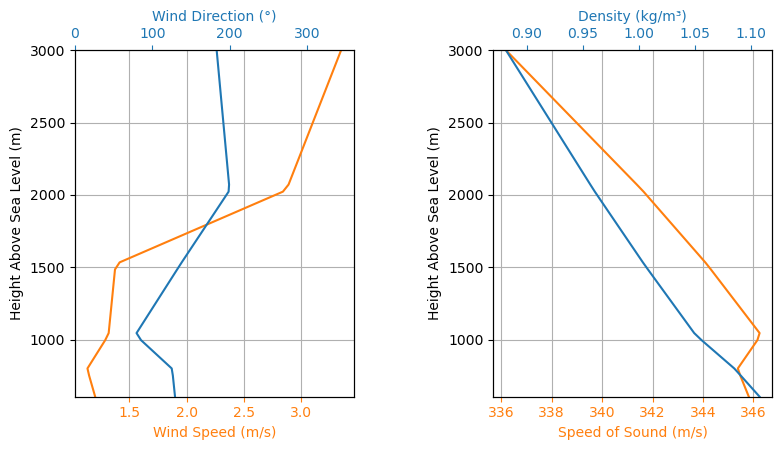

In [7]:
env_cfg = launch_data["Environment"]

env = Environment(
    date=[2026, 7, 26, 12],
    latitude=env_cfg["latitude"]["value"],
    longitude=env_cfg["longitude"]["value"],
    elevation=env_cfg["elevation"]["value"],
    timezone=env_cfg["timezone"],
)

env.set_atmospheric_model(type="windy", file="ICON")
env.max_expected_height = env_cfg["max_expected_height"]["value"]
env.info()

## Motor

Nozzle Details
Nozzle Radius: 0.045 m
Nozzle Throat Radius: 0.023 m

Grain Details
Number of Grains: 5
Grain Spacing: 0.001 m
Grain Density: 1170 kg/m3
Grain Outer Radius: 0.025 m
Grain Inner Radius: 0.01 m
Grain Height: 0.0966 m
Grain Volume: 0.000 m3
Grain Mass: 0.186 kg

Motor Details
Total Burning Time: 3.5 s
Total Propellant Mass: 0.932 kg
Structural Mass Ratio: 0.409
Average Propellant Exhaust Velocity: 2142.979 m/s
Average Thrust: 570.679 N
Maximum Thrust: 1353.5 N at 0.011 s after ignition.
Total Impulse: 1997.377 Ns



c:\Users\emide\anaconda3\envs\bisky_main\Lib\site-packages\rocketpy\motors\motor.py:990: UserWarning: burn_time argument (0, 3.5) is out of thrust source time range. Using thrust_source boundary times instead: (0, 3.451) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


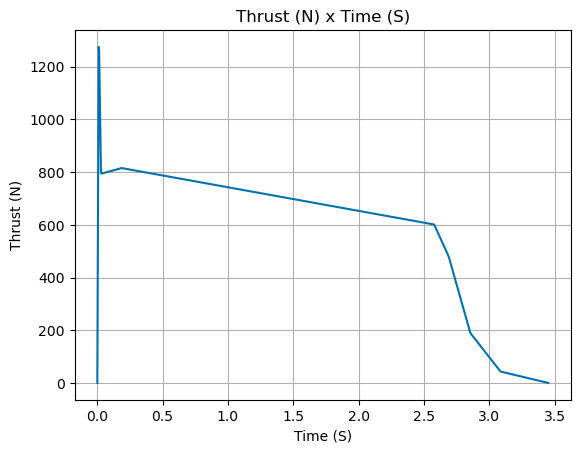

In [8]:
motor_cfg = rocket_data["motor"]

motor = SolidMotor(
    thrust_source="../../data/motors/cesaroni/Cesaroni_1997K650-21A.eng",
    burn_time=motor_cfg["motor_burn_time"]["value"],
    grain_number=int(motor_cfg["grain_number"]["value"]),
    grain_density=motor_cfg["grain_density"]["value"],
    grain_initial_inner_radius=motor_cfg["grain_initial_inner_radius"]["value"],
    grain_outer_radius=motor_cfg["grain_outer_radius"]["value"],
    grain_initial_height=motor_cfg["grain_initial_height"]["value"],
    grain_separation=motor_cfg["grain_separation"]["value"],
    grains_center_of_mass_position=motor_cfg["grains_center_of_mass_position"]["value"],
    nozzle_radius=motor_cfg["nozzle_radius"]["value"],
    throat_radius=motor_cfg["throat_radius"]["value"],
    dry_mass=motor_cfg["motor_dry_mass"]["value"],
    dry_inertia=(
        motor_cfg["motor_inertia_11"]["value"],
        motor_cfg["motor_inertia_11"]["value"],
        motor_cfg["motor_inertia_33"]["value"],
    ),
    center_of_dry_mass_position=motor_cfg["motor_dry_mass_position"]["value"],
    nozzle_position=motor_cfg["nozzle_position"]["value"],
    coordinate_system_orientation=motor_cfg["motor_coordinate_system_orientation"],
)

motor.info()

## Rocket and Aerodynamic surfaces


Inertia Details

Rocket Mass: 5.650 kg (without motor)
Rocket Dry Mass: 6.295 kg (with unloaded motor)
Rocket Loaded Mass: 7.227 kg
Rocket Structural Mass Ratio: 0.871
Rocket Inertia (with unloaded motor) 11: 2.047 kg*m2
Rocket Inertia (with unloaded motor) 22: 2.047 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.019 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.055 m
Rocket Frontal Area: 0.009503 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.061 m
Rocket Center of Dry Mass - Nozzle Exit: 0.783 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.537 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.069 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 4.927/rad
Tail Lift Coefficient Deriva

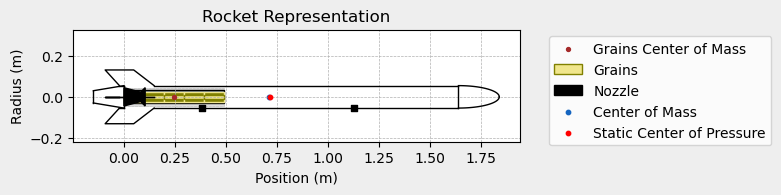

In [9]:
rocket_cfg = rocket_data["rocket"]
nose_cfg = rocket_data["nose"]
fins_cfg = rocket_data["fins"]
tail_cfg = rocket_data["tail"]
rail_cfg = rocket_data["rail_buttons"]

vlk = Rocket(
    radius=rocket_cfg["rocket_radius"]["value"],
    mass=rocket_cfg["rocket_mass"]["value"],
    inertia=(
        rocket_cfg["rocket_inertia_11"]["value"],
        rocket_cfg["rocket_inertia_11"]["value"],
        rocket_cfg["rocket_inertia_33"]["value"],
    ),
    center_of_mass_without_motor=rocket_cfg["rocket_center_of_mass_without_motor"][
        "value"
    ],
    power_off_drag=motor_cfg["power_off_drag"]["value"],
    power_on_drag=motor_cfg["power_on_drag"]["value"],
    coordinate_system_orientation=rocket_cfg["rocket_coordinate_system_orientation"],
)

vlk.set_rail_buttons(
    rail_cfg["upper_button_position"]["value"],
    rail_cfg["lower_button_position"]["value"],
    rail_cfg["rail_angular_position"]["value"],
)

vlk.add_motor(motor, position=rocket_cfg["motor_position"]["value"])

vlk.add_nose(
    length=nose_cfg["nose_length"]["value"],
    kind=nose_cfg["nose_kind"],
    position=nose_cfg["nose_position"]["value"],
)

vlk.add_trapezoidal_fins(
    n=int(fins_cfg["fin_n"]["value"]),
    span=fins_cfg["fin_span"]["value"],
    root_chord=fins_cfg["fin_root_chord"]["value"],
    tip_chord=fins_cfg["fin_tip_chord"]["value"],
    sweep_length=fins_cfg["fin_sweep_length"]["value"],
    position=fins_cfg["fin_position"]["value"],
    cant_angle=fins_cfg["fin_cant_angle"]["value"],
)

vlk.add_tail(
    top_radius=tail_cfg["top_radius"]["value"],
    bottom_radius=tail_cfg["bottom_radius"]["value"],
    length=tail_cfg["length"]["value"],
    position=tail_cfg["position"]["value"],
)

main_cfg = rocket_data["main_chute"]
drogue_cfg = rocket_data["drogue_chute"]


def main_trigger(p, h, y):
    return y[5] < 0 and h < 500


vlk.add_parachute(
    name="Drogue",
    cd_s=drogue_cfg["cd_s_drogue"]["value"],
    sampling_rate=drogue_cfg["drogue_sampling_rate"]["value"],
    lag=drogue_cfg["drogue_lag"]["value"],
    trigger="apogee",
    noise=tuple(drogue_cfg["drogue_noise"]),
)

vlk.add_parachute(
    name="Main",
    cd_s=main_cfg["cd_s_main"]["value"],
    sampling_rate=main_cfg["main_sampling_rate"]["value"],
    lag=main_cfg["main_lag"]["value"],
    trigger=main_trigger,
    noise=tuple(main_cfg["main_noise"]),
)

vlk.info()
vlk.draw()

## Flight Simulation Data

In [10]:
flight_cfg = launch_data["Flight"]
launch_cfg = launch_data["launch"]

flight = Flight(
    rocket=vlk,
    environment=env,
    rail_length=5,
    inclination=87,
    heading=30,
    max_time=2000,
)

flight.prints.apogee_conditions()


Apogee State

Apogee Time: 20.884 s
Apogee Altitude: 2852.849 m (ASL) | 2247.849 m (AGL)
Apogee Freestream Speed: 6.868 m/s
Apogee X position: 148.646 m
Apogee Y position: 170.475 m
Apogee latitude: 43.0793048°
Apogee longitude: -2.6826150°


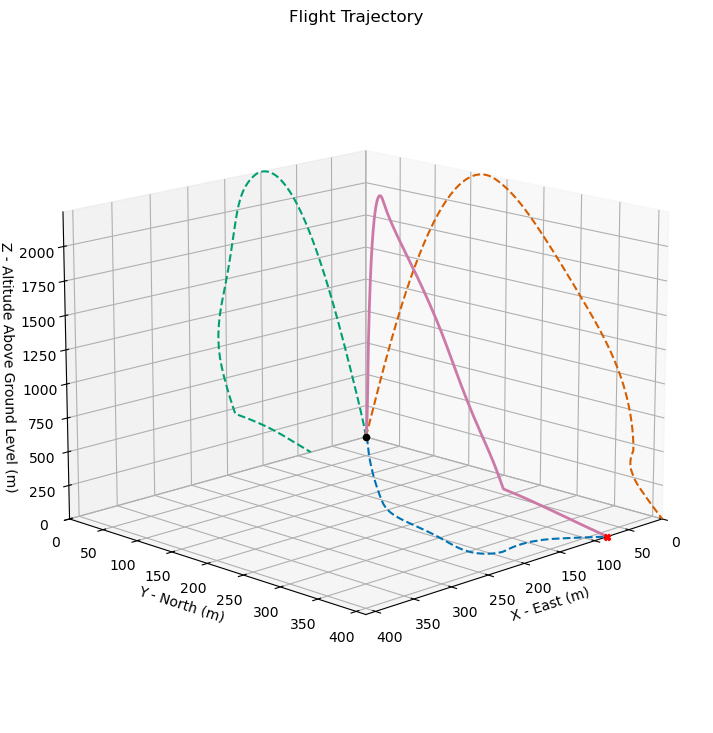

In [11]:
flight.plots.trajectory_3d()

The following attributes were create and are now available to be used:  ['time', 'altitude']


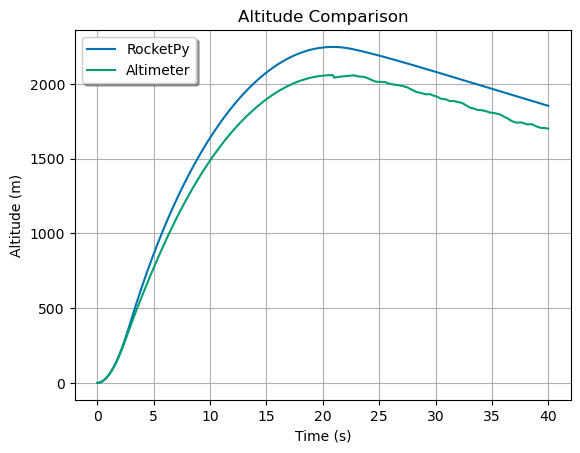

In [12]:
columns_map = {"time": "time", "altitude": "altitude"}

cots_altimeter_flight = FlightDataImporter(
    name="Altimeter Data",
    paths="../../data/rockets/valkyrie/flightInfo_merged.csv",
    columns_map=columns_map,
    units=None,
    interpolation="linear",
    extrapolation="zero",
    delimiter=",",
    encoding="utf-8",
)
Function.compare_plots(
    [
        (flight.altitude, "RocketPy"),
        (cots_altimeter_flight.altitude, "Altimeter"),
    ],
    title="Altitude Comparison",
    xlabel="Time (s)",
    ylabel="Altitude (m)",
    lower=0,
    upper=40,
)